# AI Impact on Jobs & Tech Salaries — Analysis

Two pre-aggregated datasets:
- **jobs_synthesis.csv** — AI automation risk by Risk_Category × Education_Level (n, avg_salary, avg_automation_prob, avg_ai_exposure)
- **salaries_synthesis.csv** — Tech salaries by work_year × experience_level × company_size (n, avg_salary_usd, avg_remote_ratio)

Covers: descriptive stats, groupby/aggregation, correlation, rate analysis, distribution comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

jobs = pd.read_csv('jobs_synthesis.csv')
sal = pd.read_csv('salaries_synthesis.csv')

print("jobs:", jobs.shape)
display(jobs)
print("\nsalaries:", sal.shape)
display(sal.head())

jobs: (12, 6)


,Risk_Category,Education_Level,n,avg_salary,avg_automation_prob,avg_ai_exposure
0,High,Bachelor's,188,87616.675532,0.832074,0.509521
1,High,High School,187,83841.438503,0.825508,0.501711
2,High,Master's,188,90989.228723,0.824681,0.515904
3,High,PhD,177,86947.615819,0.836102,0.512373
4,Low,Bachelor's,190,87420.594737,0.179105,0.498263
5,Low,High School,182,93598.390110,0.181978,0.495659
6,Low,Master's,188,90892.606383,0.168936,0.488457
7,Low,PhD,179,84701.776536,0.176536,0.502067
8,Medium,Bachelor's,387,90082.702842,0.496925,0.489328
9,Medium,High School,415,88154.096386,0.509904,0.496506



salaries: (65, 6)


,work_year,experience_level,company_size,n,avg_salary_usd,avg_remote_ratio
0,2020,EN,L,9,85821.555556,72.222222
1,2020,EN,M,2,31362.500000,50.000000
2,2020,EN,S,10,63153.500000,55.000000
3,2020,EX,L,3,234944.333333,83.333333
4,2020,EX,M,1,15000.000000,0.000000


## 1. Descriptive Statistics

In [2]:
print("=== Jobs dataset ===")
display(jobs.describe())

print("\n=== Salaries dataset ===")
display(sal.describe())

# n-weighted overall averages (since rows are already group means)
def weighted_avg(df, col, w='n'):
    return np.average(df[col], weights=df[w])

print("\nWeighted avg salary (jobs data):   ${:,.0f}".format(weighted_avg(jobs, 'avg_salary')))
print("Weighted avg automation prob:      {:.1%}".format(weighted_avg(jobs, 'avg_automation_prob')))
print("Weighted avg AI exposure:          {:.1%}".format(weighted_avg(jobs, 'avg_ai_exposure')))
print("\nWeighted avg salary (salaries data): ${:,.0f}".format(weighted_avg(sal, 'avg_salary_usd')))
print("Weighted avg remote ratio:           {:.1f}%".format(weighted_avg(sal, 'avg_remote_ratio')))

=== Jobs dataset ===


,n,avg_salary,avg_automation_prob,avg_ai_exposure
count,12.000000,12.000000,12.000000,12.000000
mean,250.000000,89016.343820,0.501892,0.501988
std,97.267205,3046.883834,0.278480,0.008779
min,177.000000,83841.438503,0.168936,0.488457
25%,185.750000,87302.350007,0.181260,0.496294
50%,188.000000,89118.399614,0.496740,0.501889
75%,359.250000,91170.445219,0.824888,0.509422
max,415.000000,93598.390110,0.836102,0.515904



=== Salaries dataset ===


,work_year,n,avg_salary_usd,avg_remote_ratio
count,65.000000,65.000000,65.000000,65.000000
mean,2022.323077,1125.353846,120782.521369,49.170129
std,1.621223,4918.597267,50952.473444,27.634241
min,2020.000000,1.000000,15000.000000,0.000000
25%,2021.000000,6.000000,82413.717391,25.000000
50%,2022.000000,17.000000,114906.833333,55.000000
75%,2024.000000,106.000000,157633.000000,73.076923
max,2025.000000,34682.000000,242870.500000,100.000000



Weighted avg salary (jobs data):   $89,372
Weighted avg automation prob:      50.2%
Weighted avg AI exposure:          50.1%

Weighted avg salary (salaries data): $158,014
Weighted avg remote ratio:           21.6%


## 2. Aggregation / GroupBy

In [3]:
# Jobs: risk category rollup (n-weighted)
def wavg_group(df, groupcols, valcol, wcol='n'):
    g = df.groupby(groupcols).apply(
        lambda d: np.average(d[valcol], weights=d[wcol])
    ).rename(f'wavg_{valcol}')
    return g

risk_rollup = jobs.groupby('Risk_Category').agg(
    total_n=('n', 'sum'),
    avg_salary=('avg_salary', 'mean'),
    avg_automation_prob=('avg_automation_prob', 'mean'),
    avg_ai_exposure=('avg_ai_exposure', 'mean'),
).sort_values('avg_automation_prob', ascending=False)
print("Risk category rollup:")
display(risk_rollup)

edu_rollup = jobs.groupby('Education_Level').agg(
    total_n=('n', 'sum'),
    avg_salary=('avg_salary', 'mean'),
    avg_automation_prob=('avg_automation_prob', 'mean'),
).sort_values('avg_salary', ascending=False)
print("\nEducation level rollup:")
display(edu_rollup)

Risk category rollup:


,total_n,avg_salary,avg_automation_prob,avg_ai_exposure
Risk_Category,,,,
High,740,87348.739644,0.829591,0.509877
Medium,1521,90546.949873,0.499446,0.499976
Low,739,89153.341942,0.176639,0.496112



Education level rollup:


,total_n,avg_salary,avg_automation_prob
Education_Level,,,
Master's,735,91198.643271,0.496006
High School,784,88531.308333,0.505797
Bachelor's,765,88373.324370,0.502702
PhD,716,87962.099304,0.503065


In [4]:
# Salaries: by experience level and company size
exp_rollup = sal.groupby('experience_level').agg(
    total_n=('n', 'sum'),
    avg_salary_usd=('avg_salary_usd', 'mean'),
    avg_remote_ratio=('avg_remote_ratio', 'mean'),
).sort_values('avg_salary_usd', ascending=False)
print("By experience level:")
display(exp_rollup)

size_rollup = sal.groupby('company_size').agg(
    total_n=('n', 'sum'),
    avg_salary_usd=('avg_salary_usd', 'mean'),
).sort_values('avg_salary_usd', ascending=False)
print("\nBy company size:")
display(size_rollup)

year_rollup = sal.groupby('work_year').agg(
    total_n=('n', 'sum'),
    avg_salary_usd=('avg_salary_usd', 'mean'),
).sort_index()
print("\nBy year:")
display(year_rollup)

By experience level:


,total_n,avg_salary_usd,avg_remote_ratio
experience_level,,,
EX,1494,163773.545488,54.150913
SE,42926,145157.064543,48.718506
MI,21851,105559.580914,47.035803
EN,6877,76226.545845,47.654257



By company size:


,total_n,avg_salary_usd
company_size,,
L,2407,137258.453949
M,70536,123542.079323
S,205,96050.530244



By year:


,total_n,avg_salary_usd
work_year,,
2020,75,101585.814899
2021,218,110890.558497
2022,1659,116943.515831
2023,8522,123624.172849
2024,62228,135189.563019
2025,446,146976.537966


## 3. Correlation Analysis

Jobs dataset correlation matrix (n, avg_salary, avg_automation_prob, avg_ai_exposure):


,n,avg_salary,avg_automation_prob,avg_ai_exposure
n,1.000000,0.327550,-0.003915,-0.225164
avg_salary,0.327550,1.000000,-0.258501,-0.100602
avg_automation_prob,-0.003915,-0.258501,1.000000,0.670340
avg_ai_exposure,-0.225164,-0.100602,0.670340,1.000000


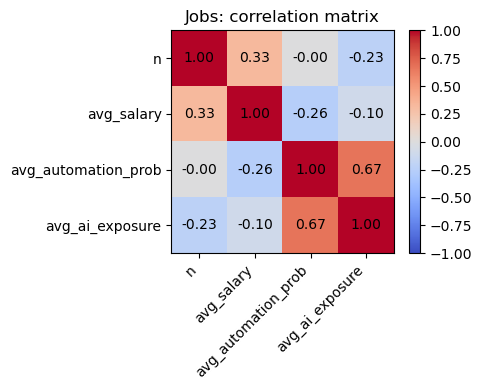

In [5]:
print("Jobs dataset correlation matrix (n, avg_salary, avg_automation_prob, avg_ai_exposure):")
jobs_corr = jobs[['n', 'avg_salary', 'avg_automation_prob', 'avg_ai_exposure']].corr()
display(jobs_corr)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(jobs_corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(jobs_corr))); ax.set_xticklabels(jobs_corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(jobs_corr))); ax.set_yticklabels(jobs_corr.columns)
for i in range(len(jobs_corr)):
    for j in range(len(jobs_corr)):
        ax.text(j, i, f'{jobs_corr.iloc[i,j]:.2f}', ha='center', va='center')
plt.colorbar(im)
plt.title('Jobs: correlation matrix')
plt.tight_layout()
plt.show()

In [6]:
print("Salaries dataset correlation (n, avg_salary_usd, avg_remote_ratio, work_year):")
sal_corr = sal[['work_year', 'n', 'avg_salary_usd', 'avg_remote_ratio']].corr()
display(sal_corr)

Salaries dataset correlation (n, avg_salary_usd, avg_remote_ratio, work_year):


,work_year,n,avg_salary_usd,avg_remote_ratio
work_year,1.000000,0.216159,0.272788,-0.621374
n,0.216159,1.000000,0.169794,-0.231975
avg_salary_usd,0.272788,0.169794,1.000000,-0.106917
avg_remote_ratio,-0.621374,-0.231975,-0.106917,1.000000


## 4. Rate Analysis

In [7]:
# Automation risk rate & AI exposure rate per education level within each risk category
jobs['automation_pct'] = jobs['avg_automation_prob'] * 100
jobs['ai_exposure_pct'] = jobs['avg_ai_exposure'] * 100
display(jobs[['Risk_Category', 'Education_Level', 'automation_pct', 'ai_exposure_pct', 'avg_salary']]
        .sort_values('automation_pct', ascending=False))

# Salary premium rate: how much more/less each education level earns vs overall weighted avg
overall_avg_salary = weighted_avg(jobs, 'avg_salary')
edu_rollup['salary_premium_pct'] = (edu_rollup['avg_salary'] / overall_avg_salary - 1) * 100
print("\nSalary premium vs overall average, by education level:")
display(edu_rollup[['avg_salary', 'salary_premium_pct']])

,Risk_Category,Education_Level,automation_pct,ai_exposure_pct,avg_salary
3,High,PhD,83.610169,51.237288,86947.615819
0,High,Bachelor's,83.207447,50.952128,87616.675532
1,High,High School,82.550802,50.171123,83841.438503
2,High,Master's,82.468085,51.590426,90989.228723
9,Medium,High School,50.990361,49.650602,88154.096386
8,Medium,Bachelor's,49.692506,48.932817,90082.702842
11,Medium,PhD,49.655556,50.938889,92236.905556
10,Medium,Master's,49.440111,50.467967,91714.094708
5,Low,High School,18.197802,49.565934,93598.390110
4,Low,Bachelor's,17.910526,49.826316,87420.594737



Salary premium vs overall average, by education level:


,avg_salary,salary_premium_pct
Education_Level,,
Master's,91198.643271,2.043547
High School,88531.308333,-0.940975
Bachelor's,88373.324370,-1.117746
PhD,87962.099304,-1.577871


In [8]:
# Remote work rate by company size and experience level (pivot)
remote_pivot = sal.pivot_table(index='experience_level', columns='company_size',
                                values='avg_remote_ratio', aggfunc='mean')
print("Avg remote-work ratio (%) by experience level x company size:")
display(remote_pivot.round(1))

# YoY salary growth rate
yoy = year_rollup.copy()
yoy['yoy_growth_pct'] = yoy['avg_salary_usd'].pct_change() * 100
print("\nYear-over-year salary growth:")
display(yoy)

Avg remote-work ratio (%) by experience level x company size:


company_size,L,M,S
experience_level,,,
EN,43.4,39.1,63.0
EX,65.8,25.7,91.7
MI,43.5,38.9,61.0
SE,36.8,46.9,65.2



Year-over-year salary growth:


,total_n,avg_salary_usd,yoy_growth_pct
work_year,,,
2020,75,101585.814899,NaN
2021,218,110890.558497,9.159491
2022,1659,116943.515831,5.458497
2023,8522,123624.172849,5.712721
2024,62228,135189.563019,9.355282
2025,446,146976.537966,8.718850


## 5. Distribution Comparison

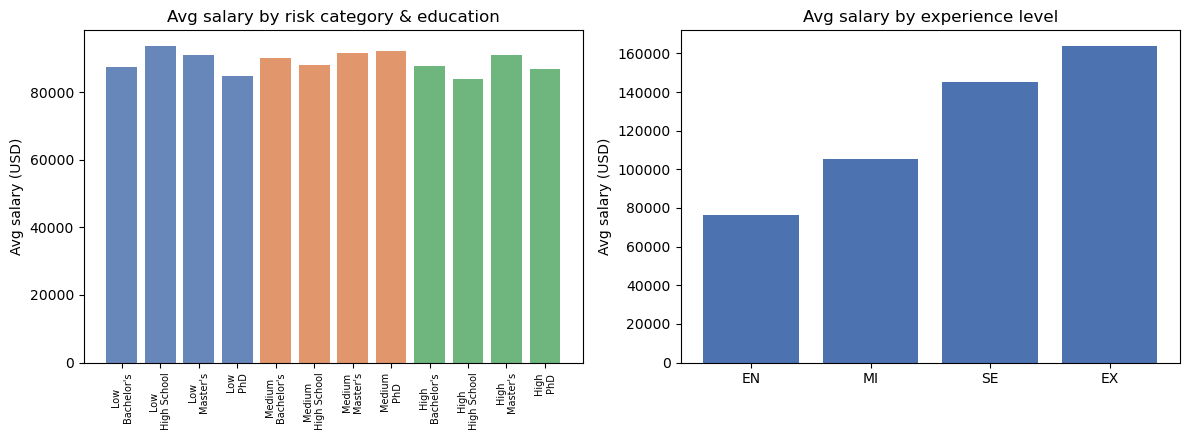

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Salary distribution by risk category (bar of group means, since data is pre-aggregated)
for i, cat in enumerate(['Low', 'Medium', 'High']):
    sub = jobs[jobs['Risk_Category'] == cat]
    axes[0].bar([f'{cat}\n{e}' for e in sub['Education_Level']], sub['avg_salary'],
                color=['#4C72B0', '#DD8452', '#55A868'][i], alpha=0.85)
axes[0].set_title('Avg salary by risk category & education')
axes[0].set_ylabel('Avg salary (USD)')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Salary distribution by experience level (salaries data)
exp_order = ['EN', 'MI', 'SE', 'EX']
axes[1].bar(exp_order, exp_rollup.reindex(exp_order)['avg_salary_usd'], color='#4C72B0')
axes[1].set_title('Avg salary by experience level')
axes[1].set_ylabel('Avg salary (USD)')

plt.tight_layout()
plt.show()

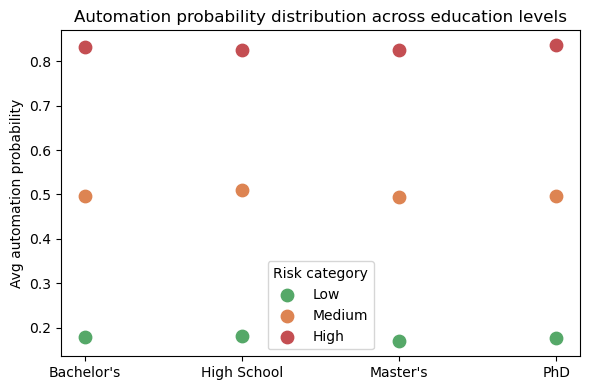

One-way ANOVA on avg_automation_prob across Risk_Category: F=11530.602, p=0.0000


In [10]:
# Automation probability distribution: High vs Medium vs Low risk
fig, ax = plt.subplots(figsize=(6, 4))
for cat, color in zip(['Low', 'Medium', 'High'], ['#55A868', '#DD8452', '#C44E52']):
    sub = jobs[jobs['Risk_Category'] == cat]
    ax.scatter(sub['Education_Level'], sub['avg_automation_prob'], label=cat, s=80, color=color)
ax.set_ylabel('Avg automation probability')
ax.set_title('Automation probability distribution across education levels')
ax.legend(title='Risk category')
plt.tight_layout()
plt.show()

# Statistical comparison: is automation prob significantly different across risk categories?
from scipy import stats
groups = [jobs[jobs['Risk_Category'] == c]['avg_automation_prob'] for c in jobs['Risk_Category'].unique()]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA on avg_automation_prob across Risk_Category: F={f_stat:.3f}, p={p_val:.4f}")

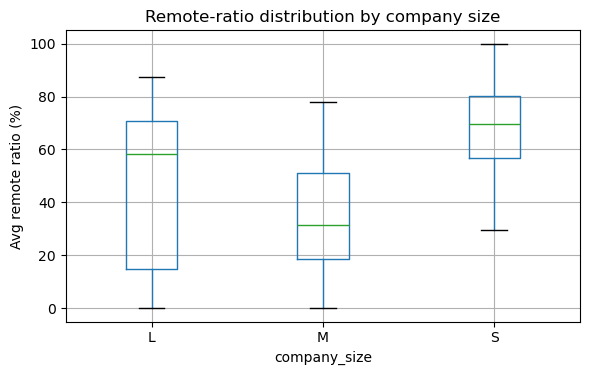

In [11]:
# Remote ratio distribution across company sizes
fig, ax = plt.subplots(figsize=(6, 4))
sal.boxplot(column='avg_remote_ratio', by='company_size', ax=ax)
ax.set_title('Remote-ratio distribution by company size')
plt.suptitle('')
ax.set_ylabel('Avg remote ratio (%)')
plt.tight_layout()
plt.show()

## Summary

- **Descriptive stats & weighted averages** computed for both datasets (n-weighted since rows are pre-aggregated group means).
- **Groupby/aggregation** by risk category, education level, experience level, company size, and year.
- **Correlation** matrices show relationships between automation probability, AI exposure, salary, and n (sample size).
- **Rate analysis** covers automation/AI-exposure percentages, salary premiums by education, remote-work rates, and YoY salary growth.
- **Distribution comparison** via bar/scatter/box plots plus a one-way ANOVA testing whether automation probability differs meaningfully across risk categories.